# 1. INTRODUCTION
<font color="royalblue">What is Netflix?</font>
Netflix is a streaming service that allows our members to watch a wide variety of award-winning TV shows, movies, documentaries, and more on thousands of internet-connected devices. With Netflix, you can enjoy unlimited ad-free viewing of our content. There's always something new to discover, and more TV shows and movies are added every month!

<font color="royalblue">TV Shows & Movies</font>
In over 190 countries, Netflix members get instant access to great content. Netflix has an extensive global content library featuring award-winning Netflix originals, feature films, documentaries, TV shows, and more. Netflix content will vary by region, and may change over time.
The more you watch, the better Netflix gets at recommending TV shows and movies you’ll love.You can play, pause, and resume watching without ads or commitments.Plus, you can download your favorite shows to your iOS or Android mobile device, or Windows 10 app. With downloads, you can watch while you're on the go and without an internet connection. Go ahead, binge a little!
![](https://upload.wikimedia.org/wikipedia/en/f/f4/Netflix_-_English.jpg)

<font color="royalblue">Streaming Devices</font>
Watch anywhere, anytime, on thousands of devices. Netflix streaming software allows you to instantly watch content from Netflix through any internet-connected device that offers the Netflix app, including smart TVs, game consoles, streaming media players, set-top boxes, smartphones, and tablets. View our Internet Speed Recommendations to achieve the best performance. You can also stream Netflix directly from your computer or laptop. We recommend reviewing the System Requirements for web browser compatibility.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.columns = [
    "id",
    "tipo",
    "titulo",
    "director",
    "reparto",
    "pais",
    "fecha_agregada",
    "anio_lanzamiento",
    "clasificacion",
    "duracion",
    "genero",
    "descripcion"
]

df.head()

,id,tipo,titulo,director,reparto,pais,fecha_agregada,anio_lanzamiento,clasificacion,duracion,genero,descripcion
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
df["tipo"] = df["tipo"].replace({
    "Movie": "Película",
    "TV Show": "Serie"
})

df.head()

,id,tipo,titulo,director,reparto,pais,fecha_agregada,anio_lanzamiento,clasificacion,duracion,genero,descripcion
0,s1,Película,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,Serie,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,Serie,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,Serie,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,Serie,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df["fecha_agregada"] = pd.to_datetime(
    df["fecha_agregada"],
    errors="coerce"
)

print(df["fecha_agregada"].head())

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: fecha_agregada, dtype: datetime64[ns]


Director con más películas:
Rajiv Chilaka    19
Name: director, dtype: int64


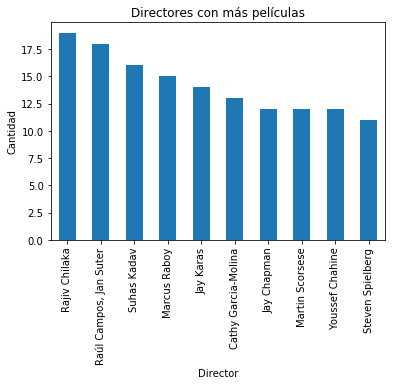

In [6]:
peliculas = df[df["tipo"] == "Película"]

top_directores = peliculas["director"].value_counts().head(10)

print("Director con más películas:")
print(top_directores.head(1))

top_directores.plot(kind="bar")

plt.title("Directores con más películas")
plt.xlabel("Director")
plt.ylabel("Cantidad")
plt.show()

United States     2058
India              893
United Kingdom     206
Canada             122
Spain               97
Name: pais, dtype: int64


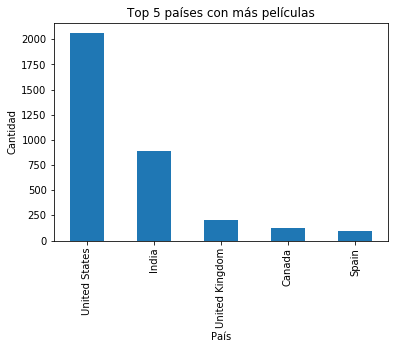

In [7]:
top_paises = peliculas["pais"].value_counts().head(5)

print(top_paises)

top_paises.plot(kind="bar")

plt.title("Top 5 países con más películas")
plt.xlabel("País")
plt.ylabel("Cantidad")
plt.show()

United States, Italy                                                                  1
United Kingdom, Finland, Germany, United States, Australia, Japan, France, Ireland    1
Luxembourg                                                                            1
Cyprus                                                                                1
Name: pais, dtype: int64


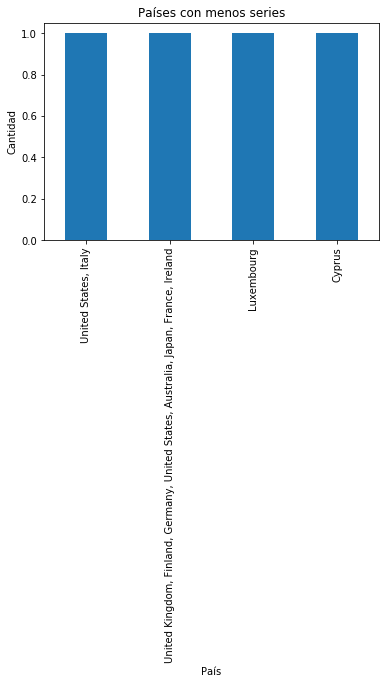

In [8]:
series = df[df["tipo"] == "Serie"]

menos_series = series["pais"].value_counts().tail(4)

print(menos_series)

menos_series.plot(kind="bar")

plt.title("Países con menos series")
plt.xlabel("País")
plt.ylabel("Cantidad")
plt.show()

In [9]:
pelicula_reciente = peliculas.sort_values(
    by="anio_lanzamiento",
    ascending=False
)

print("Película más reciente:")

print(
    pelicula_reciente[
        ["titulo", "anio_lanzamiento"]
    ].head(1)
)

Película más reciente:
               titulo  anio_lanzamiento
570  Dynasty Warriors              2021


In [10]:
series = df[df["tipo"] == "Serie"]

series = series.dropna(
    subset=["anio_lanzamiento"]
)

serie_antigua = series.sort_values(
    by="anio_lanzamiento",
    ascending=True
)

print("Serie más antigua:")

print(
    serie_antigua[
        ["titulo", "anio_lanzamiento"]
    ].head(1)
)

Serie más antigua:
                                 titulo  anio_lanzamiento
4250  Pioneers: First Women Filmmakers*              1925


/opt/conda/lib/python3.6/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


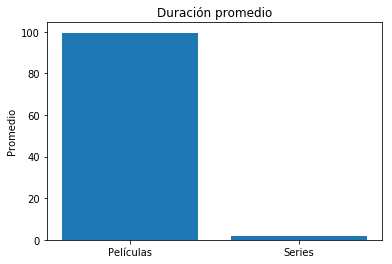

In [11]:
peliculas["duracion_num"] = peliculas[
    "duracion"
].str.extract('(\d+)').astype(float)

series["duracion_num"] = series[
    "duracion"
].str.extract('(\d+)').astype(float)

promedios = {
    "Películas": peliculas["duracion_num"].mean(),
    "Series": series["duracion_num"].mean()
}

plt.bar(
    promedios.keys(),
    promedios.values()
)

plt.title("Duración promedio")
plt.ylabel("Promedio")
plt.show()

Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: genero, dtype: int64


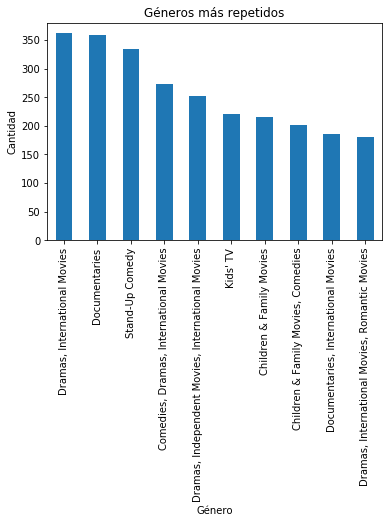

In [12]:
top_generos = df["genero"].value_counts().head(10)

print(top_generos)

top_generos.plot(kind="bar")

plt.title("Géneros más repetidos")
plt.xlabel("Género")
plt.ylabel("Cantidad")
plt.show()

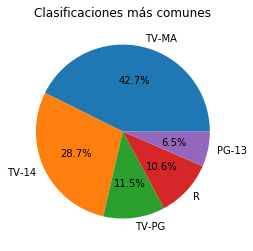

In [13]:
clasificacion = df["clasificacion"].value_counts().head(5)

clasificacion.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Clasificaciones más comunes")
plt.ylabel("")
plt.show()